In [88]:
import os
import glob
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [89]:
# STEP 1: DOWNLOAD AND LOAD THE DATASET
# =====================================================================
print("--- Step 1: Fetching data from Kaggle ---")
# Download the dataset using kagglehub as you provided
path = kagglehub.dataset_download("devzohaib/eligibility-prediction-for-loan")
print("Path to dataset files:", path)

# Dynamically locate the CSV file inside the downloaded folder path
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV files found in the downloaded directory!")

# Load the first found CSV into a pandas DataFrame
df = pd.read_csv(csv_files[0])
print(f"Dataset successfully loaded! Shape: {df.shape}\n")

# Display the first 5 rows and data types to inspect columns
print("Initial Dataset Sample:")
print(df.head())
print("\nMissing Values Count per Column:")
print(df.isnull().sum())
print("-" * 50)

--- Step 1: Fetching data from Kaggle ---
Path to dataset files: /kaggle/input/datasets/devzohaib/eligibility-prediction-for-loan
Dataset successfully loaded! Shape: (614, 13)

Initial Dataset Sample:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000           

In [90]:
# Copying dataframe to keep it clean
df_trimmed = df.copy()

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    Q1 = df_trimmed[col].quantile(0.25)
    Q3 = df_trimmed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Keep only data inside the bounds
    df_trimmed = df_trimmed[(df_trimmed[col] >= lower_bound) & (df_trimmed[col] <= upper_bound)]

print(f"Shape before trimming: {df.shape}")
print(f"Shape after aggressive trimming: {df_trimmed.shape}")

Shape before trimming: (614, 13)
Shape after aggressive trimming: (502, 13)


In [91]:
df_capped = df.copy()

for col in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']:
    # Determine the upper 95th percentile limit
    upper_limit = df_capped[col].quantile(0.95)
    # Determine the lower limit (optional, usually 0 for income)
    lower_limit = df_capped[col].quantile(0.01)
    
    # Cap values outside the thresholds
    df_capped[col] = np.where(df_capped[col] > upper_limit, upper_limit, df_capped[col])
    df_capped[col] = np.where(df_capped[col] < lower_limit, lower_limit, df_capped[col])

print("Outliers capped successfully at 1st and 95th percentiles! No rows were deleted.")
print(f"Dataset shape remains fully intact: {df_capped.shape}")

Outliers capped successfully at 1st and 95th percentiles! No rows were deleted.
Dataset shape remains fully intact: (614, 13)


In [92]:
df_log = df.copy()

# Apply log1p (log of 1 + x) to handle any potential 0 values smoothly (especially in CoapplicantIncome)
df_log['ApplicantIncome_Log'] = np.log1p(df_log['ApplicantIncome'])
df_log['CoapplicantIncome_Log'] = np.log1p(df_log['CoapplicantIncome'])
df_log['LoanAmount_Log'] = np.log1p(df_log['LoanAmount'])

# Now drop the old un-transformed columns
df_log = df_log.drop(columns=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount'])
print("Log transformations completed. Distributions normalized!")

Log transformations completed. Distributions normalized!


In [93]:
# STEP 2: DATA CLEANING & PREPROCESSING (Handling Missing Values)
# =====================================================================
print("\n--- Step 2: Cleaning Data & Handling Gaps ---")

# 1. Drop Loan_ID as it has zero predictive power (just an index)
if 'Loan_ID' in df.columns:
    df = df.drop(columns=['Loan_ID'])

# 2. Impute Categorical Columns using Mode (Most Frequent Value)
categorical_cols_with_nas = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols_with_nas:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# 3. Impute Numerical Columns using Median (Safer against outliers than Mean)
numerical_cols_with_nas = ['LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols_with_nas:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Data Cleaning Complete. Remaining Missing Values:", df.isnull().sum().sum())
print("-" * 50)


--- Step 2: Cleaning Data & Handling Gaps ---
Data Cleaning Complete. Remaining Missing Values: 0
--------------------------------------------------


          PHASE 1: EXPLORATORY DATA ANALYSIS     

--- 1. Data Shape and Data Types ---
Dataset contains 614 rows and 12 columns.

Data Types:
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

--- 2. Summary Statistics (Numerical Features) ---
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  614.000000        614.000000   
mean       5403.459283        1621.245798  145.752443        342.410423   
std        6109.041673        2926.248369   84.107233         64.428629   
min         150.000000           0.000000    9.000000         12.000000   
25%        2877.500000           0.000000  100.250000        360.000

/tmp/ipykernel_58/2519657403.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='Set2')


[Saved Plot]: eda_target_distribution.png
[Saved Plot]: eda_income_distribution.png
[Saved Plot]: eda_credit_vs_target.png
[Saved Plot]: eda_correlation_matrix.png

EDA Visualizations generated successfully!


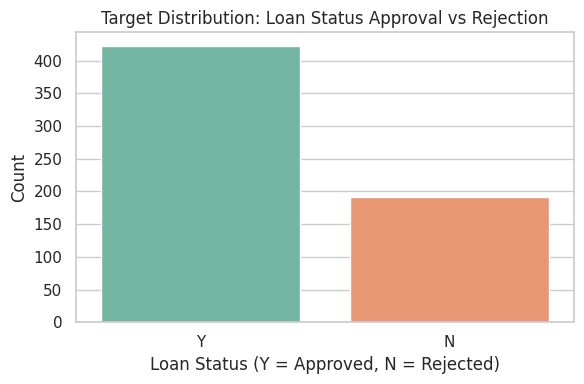

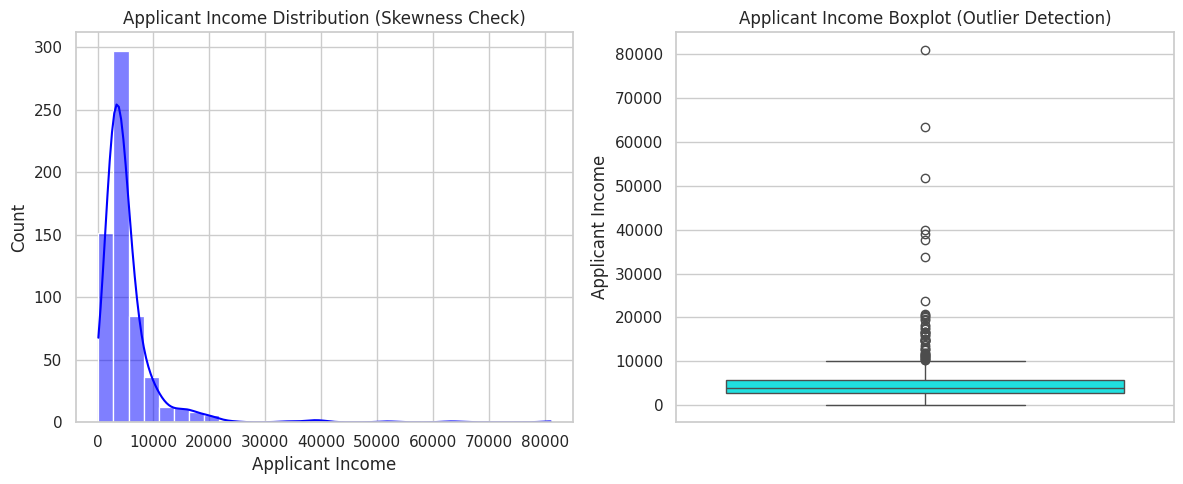

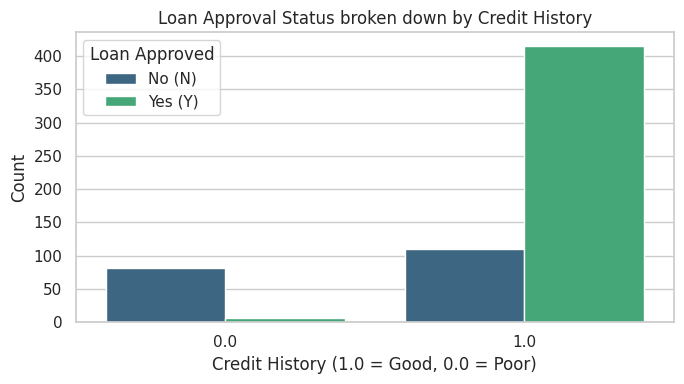

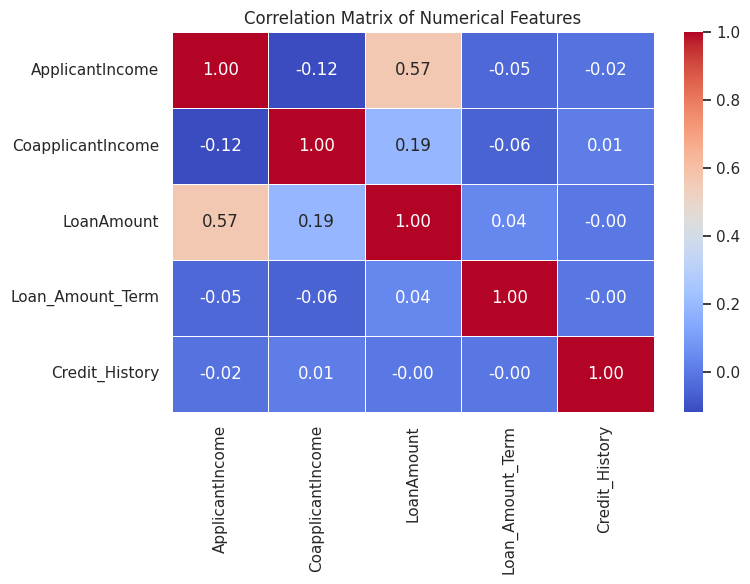

In [94]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization style
sns.set_theme(style="whitegrid")

# (Assuming df is already loaded from Step 1)
print("==================================================")
print("          PHASE 1: EXPLORATORY DATA ANALYSIS     ")
print("==================================================")

# ---------------------------------------------------------------------
# 1. Structure Check & Summary Statistics
# ---------------------------------------------------------------------
print("\n--- 1. Data Shape and Data Types ---")
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print("\nData Types:")
print(df.dtypes)

print("\n--- 2. Summary Statistics (Numerical Features) ---")
print(df.describe())

print("\n--- 3. Summary Statistics (Categorical Features) ---")
print(df.describe(include=['object']))

# ---------------------------------------------------------------------
# 2. Univariate Analysis (Visualizing Single Variables)
# ---------------------------------------------------------------------
# Plot A: Target Class Distribution (Checking for Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df, palette='Set2')
plt.title('Target Distribution: Loan Status Approval vs Rejection')
plt.xlabel('Loan Status (Y = Approved, N = Rejected)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_target_distribution.png')
print("[Saved Plot]: eda_target_distribution.png")

# Plot B: Continuous Feature Distribution & Skewness Check
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['ApplicantIncome'], kde=True, color='blue', bins=30)
plt.title('Applicant Income Distribution (Skewness Check)')
plt.xlabel('Applicant Income')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['ApplicantIncome'], color='cyan')
plt.title('Applicant Income Boxplot (Outlier Detection)')
plt.ylabel('Applicant Income')
plt.tight_layout()
plt.savefig('eda_income_distribution.png')
print("[Saved Plot]: eda_income_distribution.png")

# ---------------------------------------------------------------------
# 3. Bivariate & Multivariate Analysis (Visualizing Relationships)
# ---------------------------------------------------------------------
# Plot C: Categorical Predictor vs Target (The Credit History Impact)
plt.figure(figsize=(7, 4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, palette='viridis')
plt.title('Loan Approval Status broken down by Credit History')
plt.xlabel('Credit History (1.0 = Good, 0.0 = Poor)')
plt.ylabel('Count')
plt.legend(title='Loan Approved', labels=['No (N)', 'Yes (Y)'])
plt.tight_layout()
plt.savefig('eda_credit_vs_target.png')
print("[Saved Plot]: eda_credit_vs_target.png")

# Plot D: Correlation Heatmap for Numerical Features
plt.figure(figsize=(8, 6))
# Temporary numeric conversion to compute correlations safely
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png')
print("[Saved Plot]: eda_correlation_matrix.png")

print("\nEDA Visualizations generated successfully!")

In [95]:
print(df.isnull().sum())
print("-" * 50)

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64
--------------------------------------------------


In [96]:
df_simple = df.copy()

# 1. Handle Categorical Columns with Mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols:
    if col in df_simple.columns:
        df_simple[col] = df_simple[col].fillna(df_simple[col].mode()[0])

# 2. Handle Skewed Numerical Columns with Median
num_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    if col in df_simple.columns:
        df_simple[col] = df_simple[col].fillna(df_simple[col].median())

print(f"Simple Imputation Missing Values Left: {df_simple.isnull().sum().sum()}")

Simple Imputation Missing Values Left: 0


In [97]:
# STEP 3: FEATURE ENGINEERING & ENCODING
# =====================================================================
print("\n--- Step 3: Mapping & Encoding Categorical Columns ---")

# 1. Map the target column (Loan_Status) to Binary integers: Y -> 1 (Approved), N -> 0 (Rejected)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# 2. Convert remaining text features into structural numbers using One-Hot Encoding
# drop_first=True prevents the "Dummy Variable Trap" (multicollinearity) by eliminating redundant flags
df_encoded = pd.get_dummies(df, drop_first=True)

print("Columns after One-Hot Encoding:")
print(df_encoded.columns.tolist())
print("-" * 50)


--- Step 3: Mapping & Encoding Categorical Columns ---
Columns after One-Hot Encoding:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_Male', 'Married_Yes', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']
--------------------------------------------------


In [98]:
# STEP 4: SEPARATING FEATURES AND TARGET
# =====================================================================
# Separate independent variables (X) from our target outcome labels (y)
X = df_encoded.drop(columns=['Loan_Status'])
y = df_encoded['Loan_Status']

print(f"\nTarget Class Distribution:\n{y.value_counts(normalize=True) * 100}")
print("Notice the imbalance? Roughly 69% are approved, while 31% are rejected.")
print("-" * 50)


Target Class Distribution:
Loan_Status
1    68.729642
0    31.270358
Name: proportion, dtype: float64
Notice the imbalance? Roughly 69% are approved, while 31% are rejected.
--------------------------------------------------


In [99]:
# STEP 5: TRAIN-TEST SPLIT
# =====================================================================
# We use stratify=y to guarantee that both train and test splits hold the same 69/31 ratio of target classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print("-" * 50)


Train set size: 491 samples
Test set size: 123 samples
--------------------------------------------------


In [100]:
# STEP 6: FEATURE SCALING
# =====================================================================
print("\n--- Step 6: Standardizing Continuous Scales ---")
# Scale numerical values so huge inputs (like Income) don't overpower smaller inputs (like dependents)
scaler = StandardScaler()

# Fit only on the training data to prevent data leakage, then transform both subsets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- Step 6: Standardizing Continuous Scales ---


In [101]:
# STEP 7: MODEL TRAINING (Logistic Regression)
# =====================================================================
print("\n--- Step 7: Training Logistic Regression Model ---")
# Initialize the classifier
model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model weights using the scaled training features and target labels
model.fit(X_train_scaled, y_train)
print("Model training complete!")


--- Step 7: Training Logistic Regression Model ---
Model training complete!


In [102]:
# STEP 8: EVALUATION METRICS
# =====================================================================
print("\n--- Step 8: Evaluating Model Performance ---")
# Predict classes for the unseen testing split
y_pred = model.predict(X_test_scaled)

# Calculate Core Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)'])

print(f"Overall Test Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix Matrix Layout:")
print(conf_matrix)
print("\nDetailed Performance Matrix (Precision, Recall, F1-Score):")
print(class_report)
print("=" * 50)


--- Step 8: Evaluating Model Performance ---
Overall Test Accuracy: 86.18%

Confusion Matrix Matrix Layout:
[[22 16]
 [ 1 84]]

Detailed Performance Matrix (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

Rejected (0)       0.96      0.58      0.72        38
Approved (1)       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [103]:
import joblib

# 1. Save the trained Logistic Regression model
joblib.dump(model, 'logistic_loan_model.pkl')

# 2. Save the scaler (Crucial! You must scale future user input exactly like the training data)
joblib.dump(scaler, 'loan_scaler.pkl')

print("Model and Scaler have been successfully serialized and saved!")

Model and Scaler have been successfully serialized and saved!
